project Task-1

In [7]:
pip install  scikit-learn

In [4]:
pip install pandas


In [6]:
pip install numpy


In [5]:
pip install matplotlib

In [8]:
pip install seaborn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [12]:
df = pd.read_csv("/content/Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [13]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [14]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [15]:
df.shape

(545, 13)

In [16]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Task-2

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_794/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [31]:
df.dtypes
df = pd.get_dummies(
    df,
    drop_first=True
)

Task3-Model Building

In [38]:
X = df.drop("price",axis=1)
y = df["price"]
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
mean_absolute_error(
    y_test,
    lr_pred
)
np.sqrt(
mean_squared_error(
y_test,
lr_pred
))
r2_score(
y_test,
lr_pred
)
#MOdel2:RandomForest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(
X_train,
y_train
)
rf_pred = rf.predict(X_test)
print(
"MAE:",
mean_absolute_error(y_test,rf_pred)
)
print(
"RMSE:",
np.sqrt(mean_squared_error(y_test,rf_pred))
)
print(
"R2:",
r2_score(y_test,rf_pred)
)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


Task4

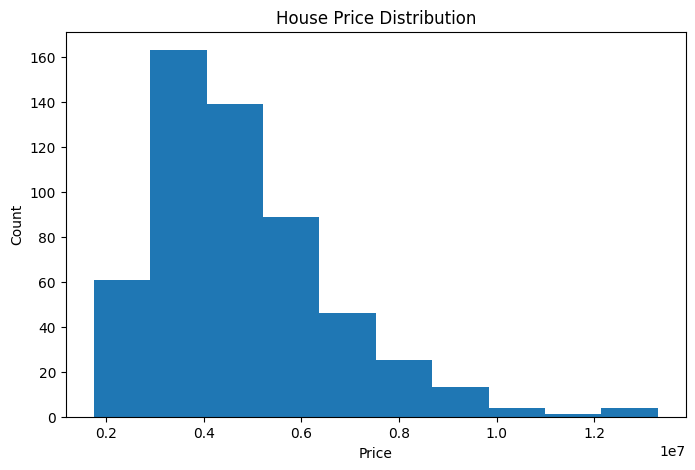

In [39]:
plt.figure(figsize=(8,5))
plt.hist(df["price"])
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("House Price Distribution")
plt.show()

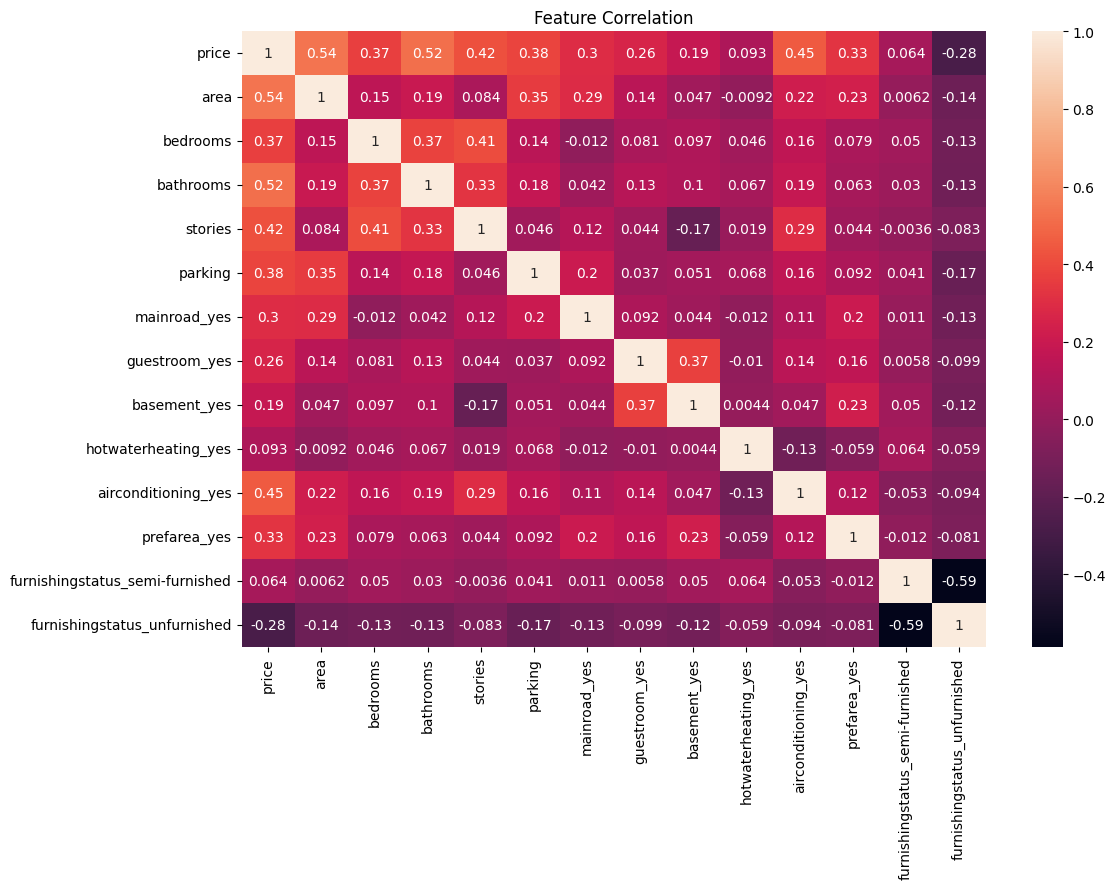

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(
df.corr(),
annot=True)
plt.title("Feature Correlation")
plt.show()

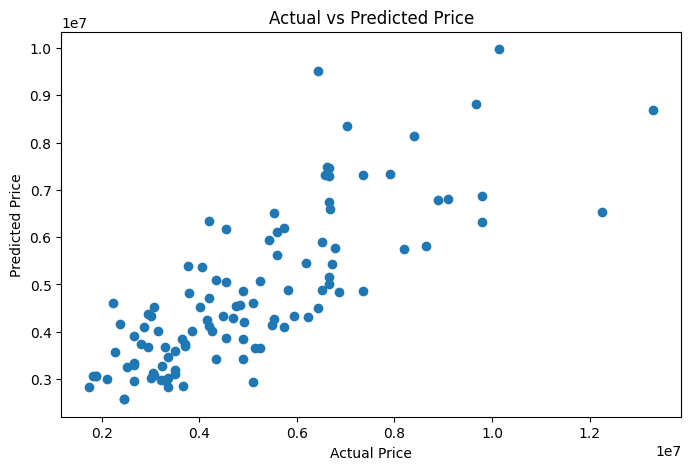

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(
y_test,
rf_pred)
plt.xlabel(
"Actual Price")
plt.ylabel(
"Predicted Price")
plt.title(
"Actual vs Predicted Price")
plt.show()

In [44]:
import os
os.makedirs("charts", exist_ok=True)
plt.savefig(
    "charts/price_distribution.png"
)

<Figure size 640x480 with 0 Axes>

# The analysis shows that area, bedrooms, bathrooms and location features influence house prices.Random Forest performed better than Linear Regression because it captures complex patterns.The model predicts house prices with good accuracy based on evaluation metrics.The surprising observation is that categorical features like air conditioning and preferred area also affect prices.This model can help real estate companies estimate property values and support better decisions.